In [2]:
from tqdm import tqdm
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 
%matplotlib inline

path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"
df = pd.read_csv(path)

print("The first 5 rows of the dataframe") 
df.head(5)

The first 5 rows of the dataframe


,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


#  Single Linear Regression

We have "CPU_frequency" is the parameter with the lowest p-value among the different features of the dataset. Create a single feature Linear Regression model that fits the pair of "CPU_frequency" and "Price" to find the model for prediction.


In [66]:
lr= LinearRegression()
x = df['CPU_frequency'].values.reshape(-1, 1)
y = df['Price'].values
lr.fit(x,y)
model= lr.predict(x)

Generate the Distribution plot for the predicted values and that of the actual values. How well did the model perform?


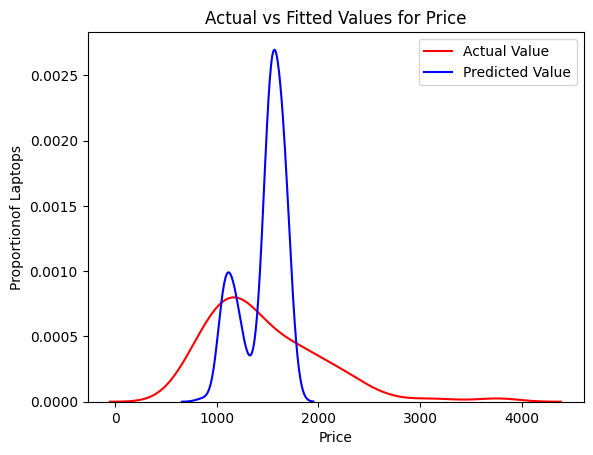

In [9]:
ax1 = sns.distplot(df['Price'], hist=False, color= "r", label= "Acctual Value")
sns.distplot(model, hist=False, color ="b", label= "Fitted Value", ax = ax1)

plt.title("Actual vs Fitted Values for Price")
plt.xlabel('Price')
plt.ylabel('Proportionof Laptops')
plt.legend(["Actual Value", "Predicted Value"])
plt.show()

Evaluate the Mean Squared Error and R^2 score values for the model. 


In [10]:
mse_slr =mean_squared_error(df['Price'], model)
r2_score_slr = lr.score(x,y)
print('the R-square for Linear Regression is :',r2_score_slr)
print('the mean square error of price and predicted value is :',mse_slr)

the R-square for Linear Regression is : 0.1344436321024326
the mean square error of price and predicted value is : 284583.4405868629


# Multiple Linear Regression
The parameters which have a low enough p-value so as to indicate strong relationship with the 'Price' value are 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU' and 'Category'. Use all these variables to create a Multiple Linear Regression system. 


In [12]:
z = df[['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category']]
lr.fit(z,y)
model1 =  lr.predict(z)

Plot the Distribution graph of the predicted values as well as the Actual values



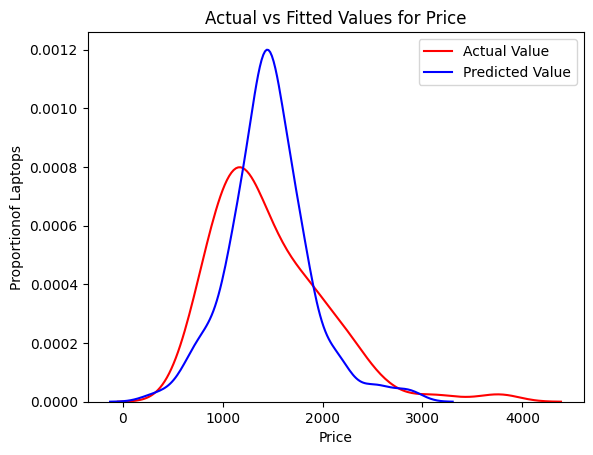

In [14]:
ax1 = sns.distplot(df['Price'],hist = False, label = "Actual Value",color= "r")
sns.distplot(model1,hist = False , label = "Fitted Value", color = "b",ax =ax1)

plt.title("Actual vs Fitted Values for Price")
plt.xlabel('Price') 
plt.ylabel('Proportionof Laptops')
plt.legend(["Actual Value", "Predicted Value"])
plt.show()



Find the R^2 score and the MSE value for this fit. Is this better or worst than the performance of Single Linear Regression?


In [ ]:
mse_slr2 =mean_squared_error(df['Price'], model1)
r2_score_slr = lr.score(z,y)
print('the R-square for Multi Linear Regression is :',r2_score_slr)
print('the mean square error of price and predicted value is :',mse_slr)

# Polynomial Regression
Use the variable "CPU_frequency" to create Polynomial features. Try this for 3 different values of polynomial degrees.

In [55]:
x = x.flatten()
f1 = np.polyfit(x,y,1)
p1 =np.poly1d(f1)

f3 = np.polyfit(x,y,3)
p3 = np.poly1d(f3)

f5 = np.polyfit(x,y,5)
p5 = np.poly1d(f5)
print(p1)
print(p3)
print(p5)

 
1485 x + 253.7
           3             2
3.409e+04 x - 6.574e+04 x + 4.129e+04 x - 7238
           5            4             3             2
1.357e+06 x - 4.72e+06 x + 6.458e+06 x - 4.336e+06 x + 1.425e+06 x - 1.818e+05


Plot the regression output against the actual data points to note how the data fits in each case. To plot the polynomial response over the actual data points


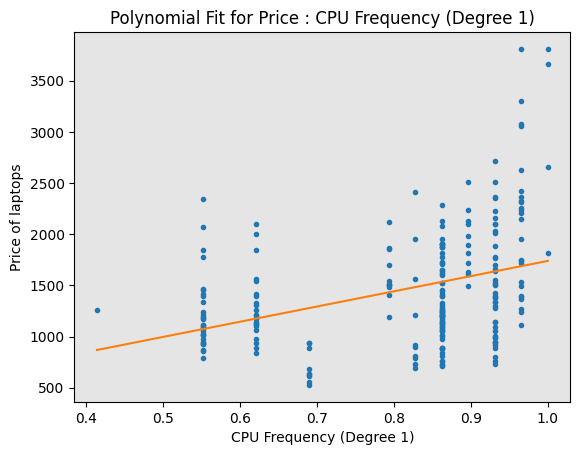

In [56]:
def PlotPolly(model,x,y, Name):
    x_new = np.linspace(x.min(),x.max(),100)
    y_new = model(x_new)

    plt.plot(x,y, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit for Price : ' + Name)
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of laptops')

PlotPolly(p1, x, y, 'CPU Frequency (Degree 1)')         


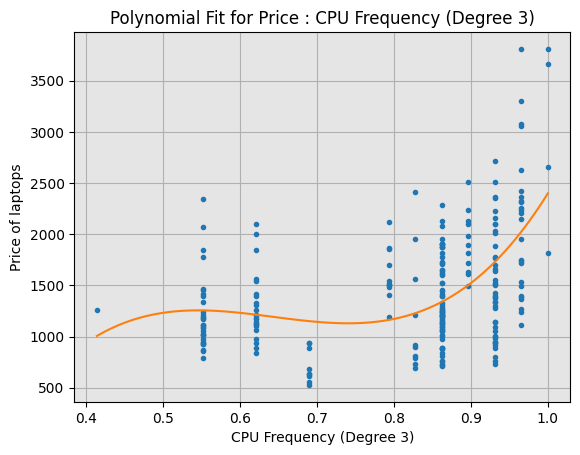

In [53]:
PlotPolly(p3, x, y, 'CPU Frequency (Degree 3)')


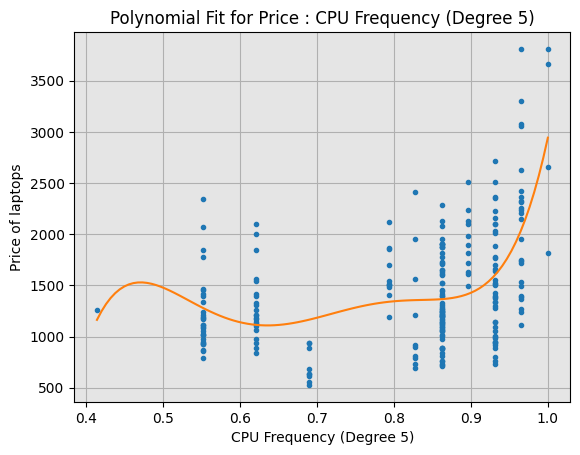

In [50]:
PlotPolly(p5, x, y, 'CPU Frequency (Degree 5)')   

calculate the R^2 and MSE values for these fits

In [68]:

mse_slr2 =mean_squared_error(df['Price'], model)
r2_score_slr = lr.score(x,y)
print('the R-square for Multi Linear Regression is :',r2_score_slr)
print('the mean square error of price and predicted value is :',mse_slr)

the R-square for Multi Linear Regression is : 0.1344436321024326
the mean square error of price and predicted value is : 284583.4405868629


# Pipeline
Create a pipeline that performs parameter scaling, Polynomial Feature generation and Linear regression. Use the set of multiple features.


In [76]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]
pipe=Pipeline(Input)
z= z.astype(float)
pipe.fit(z,y)
ypipe=pipe.predict(z)

Evaluate the MSE and R^2 values for the this predicted output.

In [77]:
print('MSE for multi-variable polynomial pipeline is: ', mean_squared_error(y, ypipe))
print('R^2 for multi-variable polynomial pipeline is: ', r2_score(y, ypipe))

MSE for multi-variable polynomial pipeline is:  120595.8612802837
R^2 for multi-variable polynomial pipeline is:  0.6332094535859659


# Using Cross validation to improve the model
Divide the dataset into x_data and y_data parameters. Here y_data is the "Price" attribute, and x_data has all other attributes in the data set.

In [7]:
y_data = df['Price']
x_data = df.drop('Price', axis=1)

Split the data set into training and testing subests such that you reserve 10% of the data set for testing purposes.


In [10]:
x_train, x_test,y_train,y_test= train_test_split(x_data,y_data,test_size = 0.10,random_state=1)
print("the number of test sample:",x_test.shape[0])
print("number of training sample:",x_train.shape[0])


the number of test sample: 24
number of training sample: 214


Create a single variable linear regression model using "CPU_frequency" parameter. Print the R^2 value of this model for the training and testing subsets.


In [12]:
lr= LinearRegression()
lr.fit(x_train[['CPU_frequency']],y_train)
print(lr.score(x_train[['CPU_frequency']],y_train))
print(lr.score(x_test[['CPU_frequency']],y_test))



0.14829792099817984
-0.06599437350393811


Run a 4-fold cross validation on the model and print the mean value of R^2 score along with its standard deviation.


In [15]:
rcross = cross_val_score(lr,x_train[['CPU_frequency']],y_train,cv=4)
print("the mean of the folds are:",rcross.mean(),"and thw standard deviation:",rcross.std())

the mean of the folds are: 0.12738818019555032 and thw standard deviation: 0.08317058010912012


# Overfitting

Split the data set into training and testing components again, this time reserving 50% of the data set for testing.

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.5, random_state=0)


To identify the point of overfitting the model on the parameter "CPU_frequency", you'll need to create polynomial features using the single attribute. 
You need to evaluate the R^2 scores of the model created using different degrees of polynomial features, ranging from 1 to 5. Save this set of values of R^2 score as a list.

In [25]:
lr = LinearRegression()
Rsqu_test = []
order = [1,2,3,4,5]
for n in order:
    pr = PolynomialFeatures(degree=n)
    x_train_pr = pr.fit_transform(x_train[['CPU_frequency']])
    x_test_pr = pr.fit_transform(x_test[['CPU_frequency']])
    lr.fit(x_train_pr,y_train)
    Rsqu_test.append(lr.score(x_test_pr,y_test))
print(Rsqu_test)

[0.05322174176198102, -0.02692081867899887, 0.0515634579255857, -0.9948137915474271, -1.375936095631023]


Plot the values of R^2 scores against the order. Note the point where the score drops.


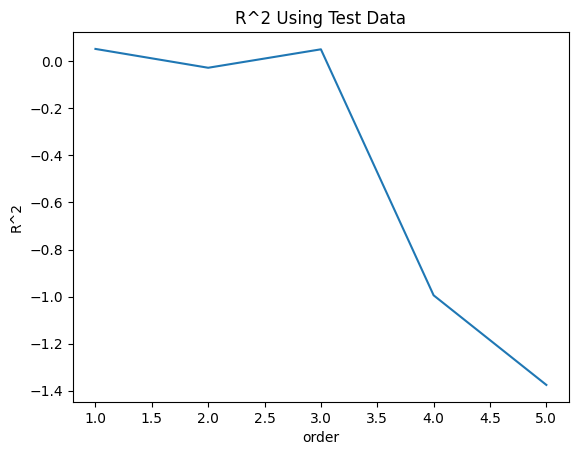

In [27]:
plt.plot(order, Rsqu_test)
plt.xlabel('order')
plt.ylabel('R^2')
plt.title('R^2 Using Test Data')
plt.show()

# Ridge Regression

Now consider that you have multiple features, i.e. 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU' and 'Category'. Create a polynomial feature model that uses all these parameters with degree=2. Also create the training and testing attribute sets.


In [30]:
pr=PolynomialFeatures(degree=2)
x_train_pr=pr.fit_transform(x_train[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']])
x_test_pr=pr.fit_transform(x_test[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']])


Create a Ridge Regression model and evaluate it using values of the hyperparameter alpha ranging from 0.001 to 1 with increments of 0.001. 
Create a list of all Ridge Regression R^2 scores for training and testing data. 

In [39]:
Rsqu_test = []
Rsqu_train = []
Alpha = np.arange(0.001,1,0.001)
pbar = tqdm(Alpha)

for alpha in pbar:
    RigeModel = Ridge(alpha=alpha) 
    RigeModel.fit(x_train_pr, y_train)
    test_score, train_score = RigeModel.score(x_test_pr, y_test), RigeModel.score(x_train_pr, y_train)
    pbar.set_postfix({"Test Score": test_score, "Train Score": train_score})
    Rsqu_test.append(test_score)
    Rsqu_train.append(train_score)



100%|██████████████████████████████████████████| 999/999 [00:02<00:00, 477.23it/s, Test Score=0.423, Train Score=0.669]


plot the R^2 values for training and testing sets with respect to the value of alpha

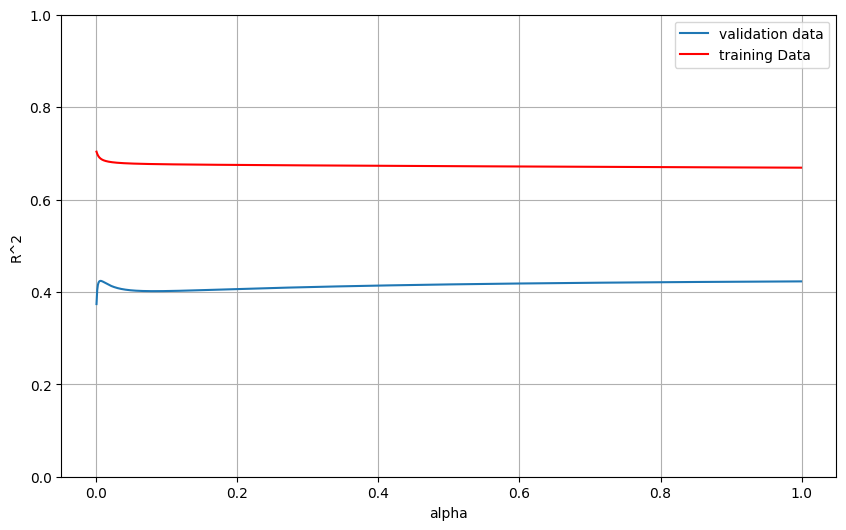

In [42]:
plt.figure(figsize=(10, 6))  
plt.plot(Alpha, Rsqu_test, label='validation data')
plt.plot(Alpha, Rsqu_train, 'r', label='training Data')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.ylim(0, 1)
plt.legend()
plt.grid(True)


# Grid Search

Using the raw data and the same set of features as used above, use GridSearchCV to identify the value of alpha for which the model performs best. 
Assume the set of alpha values to be used as
```math
{0.0001, 0.001, 0.01, 0.1, 1, 10}



In [45]:
parameter = [{'alpha':[0.0001, 0.001, 0.01, 0.1, 1, 10]}]


Create a Ridge instance and run Grid Search using a 4 fold cross validation.

In [48]:
R = Ridge()
Grid = GridSearchCV(R,parameter,cv=4)


Fit the Grid Search to the training data.

In [50]:

Grid.fit(x_train[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']], y_train)

,estimator,Ridge()
,param_grid,"[{'alpha': [0.0001, 0.001, ...]}]"
,scoring,None
,n_jobs,None
,refit,True
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,10


Print the R^2 score for the test data using the estimator that uses the derived optimum value of alpha.

In [51]:
BestRR=Grid.best_estimator_
print(BestRR.score(x_test[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU','Category']], y_test))

0.3009905048691819
